In [1]:
import pandas as pnd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras

tf.config.set_visible_devices([], 'GPU')

#Définition de la longueur et de la largeur de l'image
LONGUEUR_IMAGE = 28
LARGEUR_IMAGE = 28

#Chargement des images
observations_entrainement = pnd.read_csv('datas/fashion-mnist_train.csv')

Matplotlib is building the font cache; this may take a moment.


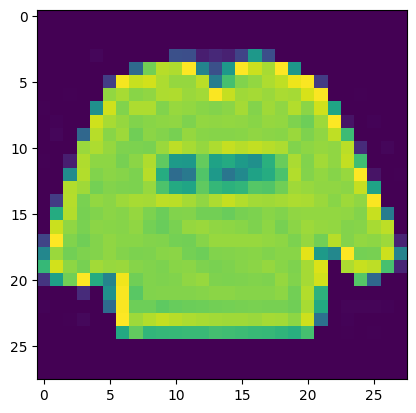

In [2]:
#On exclut la première colonne (les labels) pour constituer un tableau de pixels
X = np.array(observations_entrainement.iloc[:, 1:])

premiereImage = X[0]
premiereImage = premiereImage.reshape([LONGUEUR_IMAGE,LARGEUR_IMAGE])
plt.imshow(premiereImage)
plt.show()

In [3]:
#On crée des catégories à l'aide du module Keras
y = keras.utils.to_categorical(np.array(observations_entrainement.iloc[:,0]))
#Répartition des données d'entrainement en données d'apprentissage et données de validation
#80% de donnée d'apprentissage et 20% de donnée de validation
X_apprentissage, X_validation, y_apprentissage, y_validation = train_test_split(X, y, test_size=0.2, random_state=13)

In [4]:
# On redimensionne les images au format 28*28 et on réalise un scaling sur les données des pixels
X_apprentissage = X_apprentissage.reshape(X_apprentissage.shape[0], 
                                          LARGEUR_IMAGE, 
                                          LONGUEUR_IMAGE, 1)
X_apprentissage = X_apprentissage.astype('float32')
X_apprentissage /= 255

X_validation = X_validation.reshape(X_validation.shape[0], 
                                    LARGEUR_IMAGE, 
                                    LONGUEUR_IMAGE, 1)
X_validation = X_validation.astype('float32')
X_validation /= 255

In [5]:
#Preparation des données de tests
observations_test = pnd.read_csv('datas/fashion-mnist_test.csv')
X_test = np.array(observations_test.iloc[:, 1:])
y_test = tf.keras.utils.to_categorical(np.array(observations_test.iloc[:, 0]))
X_test = X_test.reshape(X_test.shape[0], 
                        LARGEUR_IMAGE, 
                        LONGUEUR_IMAGE, 1)
X_test = X_test.astype('float32')
X_test /= 255

In [6]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Input
from keras.layers import Conv2D, MaxPooling2D

# On spécifie les dimensions de l'image d'entrée
dimentionImage = (LARGEUR_IMAGE, LONGUEUR_IMAGE, 1)

# On crée le réseau de neurones couche par couche
reseauNeurone1Convolution = Sequential()

# Ajout de la couche d'entrée
reseauNeurone1Convolution.add(Input(shape=dimentionImage))

#1- Ajout de la couche de convolution comportant
# 32 filtres de de taille 3x3 (Kernel) parcourant l'image
# Une fonction d'activation de type ReLU (Rectified Linear Activation)
# Une image d'entrée de 28px * 28 px 
reseauNeurone1Convolution.add(Conv2D(32, 
                                     kernel_size=(3, 3), 
                                     activation='relu'))

#2- Définition de la fonction de pooling avec une fenêtre de 2px sur 2 px
reseauNeurone1Convolution.add(MaxPooling2D(pool_size=(2, 2)))

#3- Ajout d'une fonction d'ignorance
reseauNeurone1Convolution.add(Dropout(0.2))

#5 - On transforme en une seule ligne
reseauNeurone1Convolution.add(Flatten())

#6 - Ajout d'un réseau de neurones composé de 128 neurones avec 
# une fonction d'activation de type ReLU
reseauNeurone1Convolution.add(Dense(128, activation='relu'))

#7 - Ajout d'un réseau de neurones composé de 10 neurones avec une 
# fonction d'activation de type softmax
reseauNeurone1Convolution.add(Dense(10, activation='softmax'))

In [7]:
reseauNeurone1Convolution.compile(loss=keras.losses.categorical_crossentropy, 
                                  optimizer=tf.keras.optimizers.Adam(), 
                                  metrics=['accuracy'])

In [8]:
historique_apprentissage = reseauNeurone1Convolution.fit(
    X_apprentissage, 
    y_apprentissage,
    batch_size=256,
    epochs=10,
    verbose=1,
    validation_data=(X_validation, y_validation))

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.8127 - loss: 0.5389 - val_accuracy: 0.8640 - val_loss: 0.3925
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.8760 - loss: 0.3514 - val_accuracy: 0.8795 - val_loss: 0.3402
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.8905 - loss: 0.3114 - val_accuracy: 0.8802 - val_loss: 0.3366
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.8996 - loss: 0.2843 - val_accuracy: 0.8964 - val_loss: 0.3002
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.9032 - loss: 0.2709 - val_accuracy: 0.8937 - val_loss: 0.2935
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.9098 - loss: 0.2498 - val_accuracy: 0.9026 - val_loss: 0.2689
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.9153 - loss: 0.2343 - val_accuracy: 0.9050 - val_loss: 0.2702
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.9181 - loss: 0.2240 - 

In [9]:
evaluation = reseauNeurone1Convolution.evaluate(X_test, y_test, verbose=0)
print('Erreur:', evaluation[0])
print('Précision:', evaluation[1])

Erreur: 0.2528075873851776
Précision: 0.9093000292778015


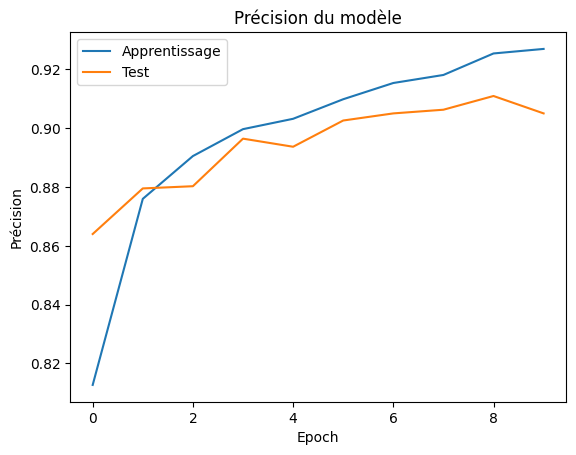

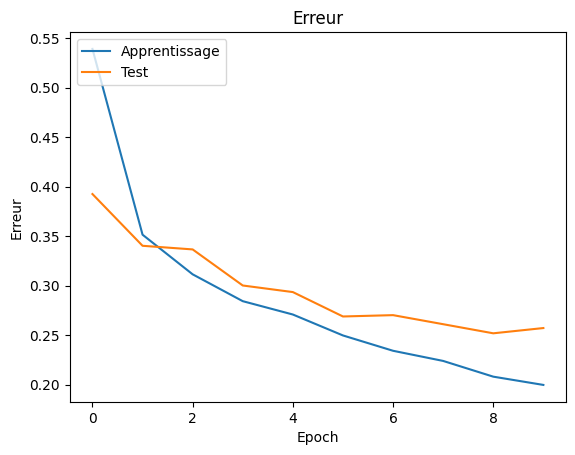

In [10]:
plt.plot(historique_apprentissage.history['accuracy'])
plt.plot(historique_apprentissage.history['val_accuracy'])
plt.title('Précision du modèle')
plt.ylabel('Précision')
plt.xlabel('Epoch')
plt.legend(['Apprentissage', 'Test'], loc='upper left')
plt.show()
# Plot training & validation loss values
plt.plot(historique_apprentissage.history['loss'])
plt.plot(historique_apprentissage.history['val_loss'])
plt.title('Erreur')
plt.ylabel('Erreur')
plt.xlabel('Epoch')
plt.legend(['Apprentissage', 'Test'], loc='upper left')
plt.show()

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

generateur_images = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=8,
    width_shift_range=0.08,
    shear_range=0.3,
    height_shift_range=0.08,
    zoom_range=0.08)

In [12]:
nouvelles_images_apprentissage = generateur_images.flow(
    X_apprentissage, 
    y_apprentissage,
    batch_size=256)

nouvelles_images_validation = generateur_images.flow(
    X_validation, 
    y_validation,
    batch_size=256)

historique_apprentissage = reseauNeurone1Convolution.fit(
    nouvelles_images_apprentissage,
    steps_per_epoch=48000//256,
    epochs=50,
    validation_data=nouvelles_images_validation,
    validation_steps=12000//256,
    verbose=1 )

evaluation = reseauNeurone1Convolution.evaluate(X_test, y_test, verbose=0)

print('Erreur :', evaluation[0])
print('Précision:', evaluation[1])

Epoch 1/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 36s 187ms/step - accuracy: 0.8286 - loss: 0.4604 - val_accuracy: 0.8350 - val_loss: 0.4401
Epoch 2/50
  1/187 ━━━━━━━━━━━━━━━━━━━━ 16s 89ms/step - accuracy: 0.8242 - loss: 0.4422

c:\Users\goufr\atelier-ml-GoufranAnd\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8242 - loss: 0.4422 - val_accuracy: 0.8371 - val_loss: 0.4272
Epoch 3/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 25s 135ms/step - accuracy: 0.8483 - loss: 0.4106 - val_accuracy: 0.8589 - val_loss: 0.3866
Epoch 4/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8984 - loss: 0.3124 - val_accuracy: 0.8559 - val_loss: 0.3891
Epoch 5/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 24s 131ms/step - accuracy: 0.8561 - loss: 0.3892 - val_accuracy: 0.8636 - val_loss: 0.3701
Epoch 6/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9141 - loss: 0.2628 - val_accuracy: 0.8603 - val_loss: 0.3749
Epoch 7/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 23s 124ms/step - accuracy: 0.8607 - loss: 0.3739 - val_accuracy: 0.8708 - val_loss: 0.3543
Epoch 8/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8281 - loss: 0.3898 - val_accuracy: 0.8647 - val_loss: 0.3613
Epoch 9/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 24s 127ms/step - accuracy: 0.8679 - loss: 0.3598 - val_accurac

In [14]:
#Sauvegarde du modèle
# Serialisation du modèle 
model_json = reseauNeurone1Convolution.to_json() 
with open("modele/modele.json", "w") as json_file:
    json_file.write(model_json)
    
# Serialisation des poids
reseauNeurone1Convolution.save_weights("modele/modele.weights.h5")
print("Modèle sauvegardé !")

Modèle sauvegardé !


In [15]:
from keras.layers import BatchNormalization

reseauNeurones4Convolution = Sequential()

reseauNeurones4Convolution.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=dimentionImage))
reseauNeurones4Convolution.add(BatchNormalization())
reseauNeurones4Convolution.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
reseauNeurones4Convolution.add(BatchNormalization())
reseauNeurones4Convolution.add(MaxPooling2D(pool_size=(2, 2)))
reseauNeurones4Convolution.add(Dropout(0.25))

reseauNeurones4Convolution.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
reseauNeurones4Convolution.add(BatchNormalization())
reseauNeurones4Convolution.add(Dropout(0.25))

reseauNeurones4Convolution.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
reseauNeurones4Convolution.add(BatchNormalization())
reseauNeurones4Convolution.add(MaxPooling2D(pool_size=(2, 2)))
reseauNeurones4Convolution.add(Dropout(0.25))

reseauNeurones4Convolution.add(Flatten())
reseauNeurones4Convolution.add(Dense(512, activation='relu'))
reseauNeurones4Convolution.add(BatchNormalization())
reseauNeurones4Convolution.add(Dropout(0.5))

reseauNeurones4Convolution.add(Dense(128, activation='relu'))
reseauNeurones4Convolution.add(BatchNormalization())
reseauNeurones4Convolution.add(Dropout(0.5))

reseauNeurones4Convolution.add(Dense(10, activation='softmax'))

c:\Users\goufr\atelier-ml-GoufranAnd\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
reseauNeurones4Convolution.compile(loss=keras.losses.categorical_crossentropy, 
                                  optimizer=tf.keras.optimizers.Adam(), 
                                  metrics=['accuracy'])

historique_apprentissage = reseauNeurones4Convolution.fit(
    X_apprentissage, 
    y_apprentissage,
    batch_size=256,
    epochs=10,
    verbose=1,
    validation_data=(X_validation, y_validation))

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 107s 535ms/step - accuracy: 0.7443 - loss: 0.7474 - val_accuracy: 0.1042 - val_loss: 3.2973
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 92s 489ms/step - accuracy: 0.8464 - loss: 0.4340 - val_accuracy: 0.5988 - val_loss: 1.3756
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 93s 492ms/step - accuracy: 0.8697 - loss: 0.3642 - val_accuracy: 0.8525 - val_loss: 0.3947
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 91s 482ms/step - accuracy: 0.8842 - loss: 0.3289 - val_accuracy: 0.8970 - val_loss: 0.2805
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 89s 474ms/step - accuracy: 0.8930 - loss: 0.2984 - val_accuracy: 0.9044 - val_loss: 0.2534
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 78s 415ms/step - accuracy: 0.8986 - loss: 0.2805 - val_accuracy: 0.8982 - val_loss: 0.2738
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 78s 414ms/step - accuracy: 0.9031 - loss: 0.2717 - val_accuracy: 0.9122 - val_loss: 0.2407
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 86s 458ms/step - accuracy: 0.9074 - loss: 

In [17]:
evaluation = reseauNeurones4Convolution.evaluate(X_test, y_test, verbose=0)
print('Erreur:', evaluation[0])
print('Précision:', evaluation[1])

Erreur: 0.22036212682724
Précision: 0.9200000166893005


In [18]:
historique_apprentissage = reseauNeurones4Convolution.fit(
    nouvelles_images_apprentissage,
    steps_per_epoch=48000//256,
    epochs=50,
    validation_data=nouvelles_images_validation,
    validation_steps=12000//256,
    verbose=1 )

evaluation = reseauNeurones4Convolution.evaluate(X_test, y_test, verbose=0)

print('Erreur :', evaluation[0])
print('Précision:', evaluation[1])

Epoch 1/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 117s 595ms/step - accuracy: 0.8539 - loss: 0.4028 - val_accuracy: 0.8521 - val_loss: 0.3916
Epoch 2/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.8672 - loss: 0.3584 - val_accuracy: 0.8581 - val_loss: 0.3808
Epoch 3/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 106s 563ms/step - accuracy: 0.8739 - loss: 0.3516 - val_accuracy: 0.8783 - val_loss: 0.3264
Epoch 4/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.8320 - loss: 0.5087 - val_accuracy: 0.8652 - val_loss: 0.3710
Epoch 5/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 112s 597ms/step - accuracy: 0.8754 - loss: 0.3446 - val_accuracy: 0.8875 - val_loss: 0.3032
Epoch 6/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.8359 - loss: 0.3923 - val_accuracy: 0.8815 - val_loss: 0.3149
Epoch 7/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 85s 452ms/step - accuracy: 0.8791 - loss: 0.3325 - val_accuracy: 0.8968 - val_loss: 0.2838
Epoch 8/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9062 - loss: 0.279

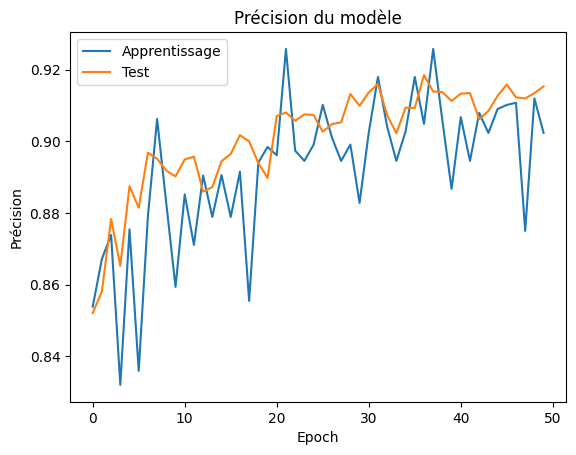

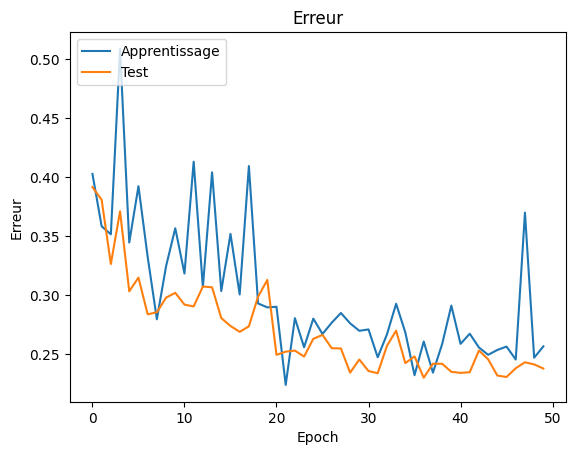

In [19]:
plt.plot(historique_apprentissage.history['accuracy'])
plt.plot(historique_apprentissage.history['val_accuracy'])
plt.title('Précision du modèle')
plt.ylabel('Précision')
plt.xlabel('Epoch')
plt.legend(['Apprentissage', 'Test'], loc='upper left')
plt.show()
# Plot training & validation loss values
plt.plot(historique_apprentissage.history['loss'])
plt.plot(historique_apprentissage.history['val_loss'])
plt.title('Erreur')
plt.ylabel('Erreur')
plt.xlabel('Epoch')
plt.legend(['Apprentissage', 'Test'], loc='upper left')
plt.show()

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

generateur_images = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=8,
    width_shift_range=0.08,
    shear_range=0.3,
    height_shift_range=0.08,
    zoom_range=0.08)

In [21]:
nouvelles_images_apprentissage = generateur_images.flow(
    X_apprentissage, 
    y_apprentissage,
    batch_size=256)

nouvelles_images_validation = generateur_images.flow(
    X_validation, 
    y_validation,
    batch_size=256)

historique_apprentissage = reseauNeurone1Convolution.fit(
    nouvelles_images_apprentissage,
    steps_per_epoch=48000//256,
    epochs=50,
    validation_data=nouvelles_images_validation,
    validation_steps=12000//256,
    verbose=1 )

evaluation = reseauNeurone1Convolution.evaluate(X_test, y_test, verbose=0)

print('Erreur :', evaluation[0])
print('Précision:', evaluation[1])

Epoch 1/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 22s 119ms/step - accuracy: 0.8963 - loss: 0.2799 - val_accuracy: 0.8851 - val_loss: 0.2974
Epoch 2/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9375 - loss: 0.1751 - val_accuracy: 0.8882 - val_loss: 0.2974
Epoch 3/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 19s 101ms/step - accuracy: 0.8974 - loss: 0.2788 - val_accuracy: 0.8901 - val_loss: 0.2934
Epoch 4/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9219 - loss: 0.2220 - val_accuracy: 0.8920 - val_loss: 0.2915
Epoch 5/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 18s 97ms/step - accuracy: 0.8963 - loss: 0.2774 - val_accuracy: 0.8923 - val_loss: 0.2813
Epoch 6/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8438 - loss: 0.3365 - val_accuracy: 0.8937 - val_loss: 0.2851
Epoch 7/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 18s 96ms/step - accuracy: 0.8991 - loss: 0.2694 - val_accuracy: 0.8967 - val_loss: 0.2850
Epoch 8/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8750 - loss: 0.3136 - val

In [22]:
#Sauvegarde du modèle
# Serialisation du modèle 
model_json = reseauNeurone1Convolution.to_json() 
with open("modele/modele.json", "w") as json_file:
    json_file.write(model_json)
    
# Serialisation des poids
reseauNeurone1Convolution.save_weights("modele/modele.weights.h5")
print("Modèle sauvegardé !")

Modèle sauvegardé !


In [23]:
from keras.layers import BatchNormalization

reseauNeurones4Convolution = Sequential()

reseauNeurones4Convolution.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=dimentionImage))
reseauNeurones4Convolution.add(BatchNormalization())
reseauNeurones4Convolution.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
reseauNeurones4Convolution.add(BatchNormalization())
reseauNeurones4Convolution.add(MaxPooling2D(pool_size=(2, 2)))
reseauNeurones4Convolution.add(Dropout(0.25))

reseauNeurones4Convolution.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
reseauNeurones4Convolution.add(BatchNormalization())
reseauNeurones4Convolution.add(Dropout(0.25))

reseauNeurones4Convolution.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
reseauNeurones4Convolution.add(BatchNormalization())
reseauNeurones4Convolution.add(MaxPooling2D(pool_size=(2, 2)))
reseauNeurones4Convolution.add(Dropout(0.25))

reseauNeurones4Convolution.add(Flatten())
reseauNeurones4Convolution.add(Dense(512, activation='relu'))
reseauNeurones4Convolution.add(BatchNormalization())
reseauNeurones4Convolution.add(Dropout(0.5))

reseauNeurones4Convolution.add(Dense(128, activation='relu'))
reseauNeurones4Convolution.add(BatchNormalization())
reseauNeurones4Convolution.add(Dropout(0.5))

reseauNeurones4Convolution.add(Dense(10, activation='softmax'))

In [24]:
reseauNeurones4Convolution.compile(loss=keras.losses.categorical_crossentropy, 
                                  optimizer=tf.keras.optimizers.Adam(), 
                                  metrics=['accuracy'])

historique_apprentissage = reseauNeurones4Convolution.fit(
    X_apprentissage, 
    y_apprentissage,
    batch_size=256,
    epochs=10,
    verbose=1,
    validation_data=(X_validation, y_validation))

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 72s 364ms/step - accuracy: 0.7386 - loss: 0.7426 - val_accuracy: 0.1053 - val_loss: 4.0016
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 67s 358ms/step - accuracy: 0.8438 - loss: 0.4361 - val_accuracy: 0.3388 - val_loss: 2.7377
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 67s 355ms/step - accuracy: 0.8715 - loss: 0.3627 - val_accuracy: 0.7813 - val_loss: 0.6278
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 73s 390ms/step - accuracy: 0.8818 - loss: 0.3298 - val_accuracy: 0.8916 - val_loss: 0.2933
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 75s 399ms/step - accuracy: 0.8921 - loss: 0.3046 - val_accuracy: 0.8985 - val_loss: 0.2712
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 82s 437ms/step - accuracy: 0.8999 - loss: 0.2828 - val_accuracy: 0.8949 - val_loss: 0.2719
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 78s 413ms/step - accuracy: 0.9041 - loss: 0.2686 - val_accuracy: 0.8939 - val_loss: 0.2851
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 74s 391ms/step - accuracy: 0.9076 - loss: 0

In [25]:
evaluation = reseauNeurone1Convolution.evaluate(X_test, y_test, verbose=0)
print('Erreur:', evaluation[0])
print('Précision:', evaluation[1])

Erreur: 0.2346256524324417
Précision: 0.9175999760627747


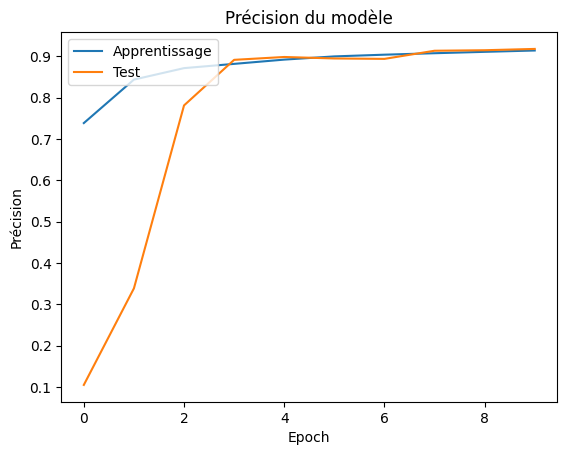

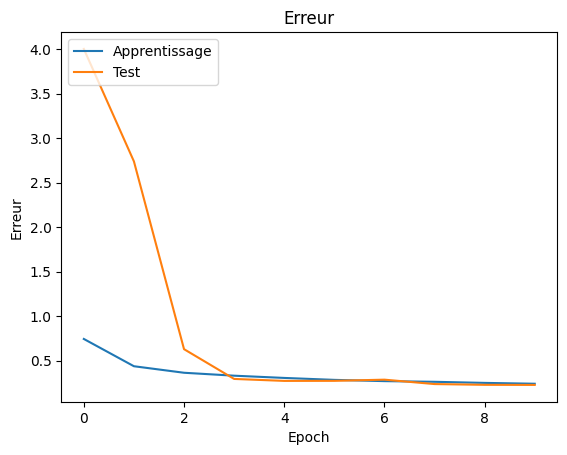

In [26]:
plt.plot(historique_apprentissage.history['accuracy'])
plt.plot(historique_apprentissage.history['val_accuracy'])
plt.title('Précision du modèle')
plt.ylabel('Précision')
plt.xlabel('Epoch')
plt.legend(['Apprentissage', 'Test'], loc='upper left')
plt.show()
# Plot training & validation loss values
plt.plot(historique_apprentissage.history['loss'])
plt.plot(historique_apprentissage.history['val_loss'])
plt.title('Erreur')
plt.ylabel('Erreur')
plt.xlabel('Epoch')
plt.legend(['Apprentissage', 'Test'], loc='upper left')
plt.show()

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

generateur_images = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=8,
    width_shift_range=0.08,
    shear_range=0.3,
    height_shift_range=0.08,
    zoom_range=0.08)

In [28]:
nouvelles_images_apprentissage = generateur_images.flow(
    X_apprentissage, 
    y_apprentissage,
    batch_size=256)

nouvelles_images_validation = generateur_images.flow(
    X_validation, 
    y_validation,
    batch_size=256)

historique_apprentissage = reseauNeurone1Convolution.fit(
    nouvelles_images_apprentissage,
    steps_per_epoch=48000//256,
    epochs=50,
    validation_data=nouvelles_images_validation,
    validation_steps=12000//256,
    verbose=1 )

evaluation = reseauNeurone1Convolution.evaluate(X_test, y_test, verbose=0)

print('Erreur :', evaluation[0])
print('Précision:', evaluation[1])

Epoch 1/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 38s 203ms/step - accuracy: 0.9090 - loss: 0.2452 - val_accuracy: 0.9035 - val_loss: 0.2617
Epoch 2/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9180 - loss: 0.2091 - val_accuracy: 0.9029 - val_loss: 0.2725
Epoch 3/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 50s 266ms/step - accuracy: 0.9088 - loss: 0.2451 - val_accuracy: 0.8980 - val_loss: 0.2725
Epoch 4/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.9258 - loss: 0.2268 - val_accuracy: 0.9001 - val_loss: 0.2684
Epoch 5/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 43s 230ms/step - accuracy: 0.9097 - loss: 0.2441 - val_accuracy: 0.9064 - val_loss: 0.2599
Epoch 6/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9336 - loss: 0.1903 - val_accuracy: 0.9040 - val_loss: 0.2680
Epoch 7/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 50s 267ms/step - accuracy: 0.9102 - loss: 0.2430 - val_accuracy: 0.8992 - val_loss: 0.2776
Epoch 8/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.9102 - loss: 0.2221 - 

In [29]:
#Sauvegarde du modèle
# Serialisation du modèle 
model_json = reseauNeurone1Convolution.to_json() 
with open("modele/modele.json", "w") as json_file:
    json_file.write(model_json)
    
# Serialisation des poids
reseauNeurone1Convolution.save_weights("modele/modele.weights.h5")
print("Modèle sauvegardé !")

Modèle sauvegardé !


In [30]:
from keras.layers import BatchNormalization

reseauNeurones4Convolution = Sequential()

reseauNeurones4Convolution.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=dimentionImage))
reseauNeurones4Convolution.add(BatchNormalization())
reseauNeurones4Convolution.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
reseauNeurones4Convolution.add(BatchNormalization())
reseauNeurones4Convolution.add(MaxPooling2D(pool_size=(2, 2)))
reseauNeurones4Convolution.add(Dropout(0.25))

reseauNeurones4Convolution.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
reseauNeurones4Convolution.add(BatchNormalization())
reseauNeurones4Convolution.add(Dropout(0.25))

reseauNeurones4Convolution.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
reseauNeurones4Convolution.add(BatchNormalization())
reseauNeurones4Convolution.add(MaxPooling2D(pool_size=(2, 2)))
reseauNeurones4Convolution.add(Dropout(0.25))

reseauNeurones4Convolution.add(Flatten())
reseauNeurones4Convolution.add(Dense(512, activation='relu'))
reseauNeurones4Convolution.add(BatchNormalization())
reseauNeurones4Convolution.add(Dropout(0.5))

reseauNeurones4Convolution.add(Dense(128, activation='relu'))
reseauNeurones4Convolution.add(BatchNormalization())
reseauNeurones4Convolution.add(Dropout(0.5))

reseauNeurones4Convolution.add(Dense(10, activation='softmax'))

In [31]:
reseauNeurones4Convolution.compile(loss=keras.losses.categorical_crossentropy, 
                                  optimizer=tf.keras.optimizers.Adam(), 
                                  metrics=['accuracy'])

historique_apprentissage = reseauNeurones4Convolution.fit(
    X_apprentissage, 
    y_apprentissage,
    batch_size=256,
    epochs=10,
    verbose=1,
    validation_data=(X_validation, y_validation))

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 94s 424ms/step - accuracy: 0.7389 - loss: 0.7455 - val_accuracy: 0.2833 - val_loss: 2.1248
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 78s 413ms/step - accuracy: 0.8435 - loss: 0.4398 - val_accuracy: 0.5560 - val_loss: 1.3874
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 83s 443ms/step - accuracy: 0.8676 - loss: 0.3688 - val_accuracy: 0.8175 - val_loss: 0.5244
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 153s 815ms/step - accuracy: 0.8826 - loss: 0.3307 - val_accuracy: 0.8723 - val_loss: 0.3426
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 155s 824ms/step - accuracy: 0.8918 - loss: 0.3042 - val_accuracy: 0.8857 - val_loss: 0.3094
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 140s 742ms/step - accuracy: 0.9003 - loss: 0.2823 - val_accuracy: 0.9064 - val_loss: 0.2615
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 154s 820ms/step - accuracy: 0.9031 - loss: 0.2706 - val_accuracy: 0.9068 - val_loss: 0.2555
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 647s 3s/step - accuracy: 0.9086 - loss:

In [32]:
evaluation = reseauNeurones4Convolution.evaluate(X_test, y_test, verbose=0)
print('Erreur:', evaluation[0])
print('Précision:', evaluation[1])

Erreur: 0.24748004972934723
Précision: 0.9107999801635742
